In [1]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

color_palette = {}
color_palette['wt'] = 'blue'
color_palette['mutated'] = 'red'
color_palette['heterozygous'] = 'orange'

import seaborn as sns
import numpy as np

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


In [2]:
lib = '2'
BC = 'BC004'

adata_dir = large_data_dir + 'MPN_WTA/MPN_' + lib + '_' + BC + '_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)

gf_utils.assign_genotypes(adata)

In [3]:
color_palette = dict(zip(adata.obs['cell_type'].cat.categories, adata.uns['cell_type_colors']))

adata.obs.loc[adata.obs['cell_type'] == 'Classical monocyte 2 (non-HSPC)','cell_type'] = 'Classical monocyte (non-HSPC)'
adata = adata[adata.obs['cell_type'] != 'Monocyte/Platelet doublet (non-HSPC)']

In [4]:
adata.obs['clone'] = pd.read_csv('../output/' + lib + '_' + BC + '_clone_assignments.txt', sep='\t',index_col=0)['clone']

/tmp/ipykernel_405709/3549063455.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clone'] = pd.read_csv('../output/' + lib + '_' + BC + '_clone_assignments.txt', sep='\t',index_col=0)['clone']


In [5]:
adata.obs['clone'].fillna('unassigned', inplace=True)

/tmp/ipykernel_405709/4199171073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs['clone'].fillna('unassigned', inplace=True)


In [6]:
adata.obs['clone'].value_counts()

clone
MPL_PTPN11    7434
MPL_RUNX1     1266
unassigned    1214
MPL           1134
JAK2            22
Name: count, dtype: int64

/tmp/ipykernel_405709/257496615.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df.index, rotation=45, ha='right')


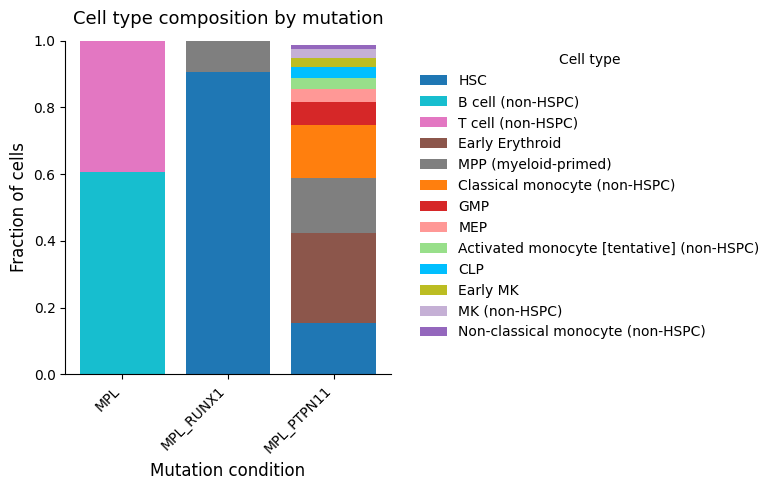

In [7]:
# Define mutation conditions and their labels
conditions = [
    (adata.obs['clone'] == 'MPL'),
    (adata.obs['clone'] == 'MPL_RUNX1'),
    (adata.obs['clone'] == 'MPL_PTPN11'),
    (adata.obs['clone'] == 'JAK2')
]
labels = ['MPL', 'MPL_RUNX1', 'MPL_PTPN11']

# Build normalized cell-type frequency table
freq_df = []
for cond, label in zip(conditions, labels):
    subset = adata[cond].obs['cell_type'].value_counts(normalize=True)
    tmp = pd.DataFrame(subset).reset_index()
    tmp.columns = ['cell_type', 'fraction']
    tmp['condition'] = label
    freq_df.append(tmp)

freq_df = pd.concat(freq_df)

# Pivot into wide format
plot_df = freq_df.pivot_table(index='condition', columns='cell_type', values='fraction', fill_value=0)

# Ensure the specified order on x-axis
plot_df = plot_df.reindex(['MPL','MPL_RUNX1', 'MPL_PTPN11', 'JAK2'])

# Reorder columns by overall abundance (optional aesthetic)
plot_df = plot_df[plot_df.sum().sort_values(ascending=False).index]
plot_df = plot_df.loc[:,plot_df.max() > 0.01].copy()

# --- Manually set first three columns ---
manual_first = ['HSC']
remaining = [col for col in plot_df.columns if col not in manual_first]
plot_df = plot_df[manual_first + remaining]

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(plot_df))
for cell_type in plot_df.columns:
    vals = plot_df[cell_type].values
    color = color_palette.get(cell_type, 'gray')  # fallback color
    ax.bar(plot_df.index, vals, bottom=bottom, color=color, edgecolor='none', label=cell_type)
    bottom += vals

# Styling
ax.set_ylabel('Fraction of cells', fontsize=12)
ax.set_xlabel('Mutation condition', fontsize=12)
ax.set_title('Cell type composition by mutation', fontsize=13, pad=12)
ax.set_ylim(0, 1)
ax.set_xticklabels(plot_df.index, rotation=45, ha='right')

# Legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Cell type', frameon=False)
sns.despine()

plt.tight_layout()
plt.savefig('../plots/' + lib + '_' + BC + '_stacked_bar_cell_type_by_mutation.pdf', bbox_inches='tight')

